# Detecting Unfair Clauses in Consumer Terms of Service : Natural Language Processing
## MSc Assignment : NLP with Machine Learning

This notebook performs Exploratory Data Analysis on the Claudette dataset, builds and compares four machine learning models (2 traditional ML + 2 deep learning) for the binary classification of sentences in online Terms of Service documents as **fair** or **unfair**, using the CLAUDETTE dataset (Lippi et al., 2019; Ruggeri et al., 2022).

**Dataset:** ToS-100, with 20,417 sentences from 100 online platform Terms of Service documents, annotated across 8 unfairness categories by legal experts.

**Original paper:** Lippi et al. (2019), *CLAUDETTE: an automated detector of potentially unfair clauses in online terms of service*, Artificial Intelligence and Law, 27(2), 117–139.

## 1. Setup and Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
pip install --upgrade pip

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


In [4]:
pip install gensim

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install -U typing-extensions

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [6]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [7]:
pip install accelerate>=1.1.0

Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install torch transformers

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [9]:
#importing libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re, os, sys
import random
import spacy
from wordcloud import WordCloud
import gensim
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS

# scikit-learn
from sklearn.feature_extraction.text import TfidfTransformer, CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
recall_score, classification_report, 
roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

# tensorflow 
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
tf.random.set_seed(42)

# torch 
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from torch.utils.data import Dataset as TorchDataset

# Set seed for reproducibility
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Reproducibility
random.seed(42)
np.random.seed(42)

# Plotting defaults
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

In [10]:
!{sys.executable} -m pip install --upgrade accelerate

'C:\Program' is not recognized as an internal or external command,
operable program or batch file.


In [11]:
from gensim.utils import simple_preprocess

## 2. Loading the Dataset

In [12]:
df = pd.read_csv('ToS-100.csv')
# Define label columns and their human readable names
LABEL_COLS = ['A', 'CH', 'CR', 'J', 'LAW', 'LTD', 'TER', 'USE']
LABEL_NAMES = {
    'A':   'Arbitration',
    'CH':  'Unilateral Change',
    'CR':  'Content Removal',
    'J':   'Jurisdiction',
    'LAW': 'Choice of Law',
    'LTD': 'Limitation of Liability',
    'TER': 'Unilateral Termination',
    'USE': 'Contract by Using'
}
print(f"Dataset: {df.shape[0]:,} sentences, {df.shape[1]} columns")
print(f"Unique documents (companies): {df['document'].nunique()}")
print(f"\nColumns: {df.columns.tolist()}")

Dataset: 20,417 sentences, 19 columns
Unique documents (companies): 100

Columns: ['Unnamed: 0', 'A', 'CH', 'CR', 'J', 'LAW', 'LTD', 'PINC', 'TER', 'USE', 'document', 'document_ID', 'label', 'text', 'TER_targets', 'LTD_targets', 'A_targets', 'CH_targets', 'CR_targets']


In [13]:
# Inspecting the dataset
print("First 3 rows:")
print(df[['text', 'label', 'document'] + LABEL_COLS].head(3).to_string())
print(f"\nSample documents: {df['document'].unique()[:10].tolist()}")

First 3 rows:
                                                                                                                                                                                                                                                                                                                                                                                                  text  label document  A  CH  CR  J  LAW  LTD  TER  USE
0                                                                                                                                                                                                                                                                                                                                                               websites & communications terms of use      0  Mozilla  0   0   0  0    0    0    0    0
1  please read the terms of this entire document -lrb- `` terms '' -rrb- carefully because it explains y

## 3. Dataset Structure and Properties

#### 3.1. Shape, types, missing values per split

In [14]:
print("DATASET OVERVIEW")
print(f"Total sentences:           {len(df):,}")
print(f"Total documents (ToS):     {df['document'].nunique()}")
print(f"Columns:                   {df.shape[1]}")
print(f"Missing values in 'text':  {df['text'].isna().sum()}")
print(f"Missing values in 'label': {df['label'].isna().sum()}")
print()
print("Data types:")
print(df[['text', 'label', 'document'] + LABEL_COLS].dtypes)

DATASET OVERVIEW
Total sentences:           20,417
Total documents (ToS):     100
Columns:                   19
Missing values in 'text':  0
Missing values in 'label': 0

Data types:
text        object
label        int64
document    object
A            int64
CH           int64
CR           int64
J            int64
LAW          int64
LTD          int64
TER          int64
USE          int64
dtype: object


#### 3.2. Show sample fair and unfair sentences

In [15]:
print("Samples of Fair sentences")
for _, row in df[df['label'] == 0].sample(3, random_state=42).iterrows():
    print(f"  [{row['document']}]")
    print(f"  \"{row['text'][:150].strip()}\"")
    print()

print("Samples of Unfair sentences")
for _, row in df[df['label'] == 1].sample(3, random_state=42).iterrows():
    active = [LABEL_NAMES[c] for c in LABEL_COLS if row[c] == 1]
    print(f"  [{row['document']}] Categories: {active}")
    print(f"  \"{row['text'][:200].strip()}\"")
    print()

Samples of Fair sentences
  [Shazam]
  "if any provision of these terms is found to be unlawful , void , or for any reason unenforceable , then the provision will be deleted ."

  [Yelp]
  "access , retrieve or index any portion of the site for purposes of constructing or populating a searchable database of business reviews ;"

  [Skyscanner]
  "in particular , we grant such licence to you subject to you agreeing that you shall not :"

Samples of Unfair sentences
  [Google] Categories: ['Unilateral Change']
  "we may add or remove functionalities or features ."

  [Groupon] Categories: ['Choice of Law']
  "you and groupon agree that the federal arbitration act , the aaa rules , applicable federal law , and the laws of the state of illinois , without regard to principles of conflicts of law , will govern"

  [Vimeo] Categories: ['Jurisdiction']
  "disputes : any action arising out of or relating to this agreement or your use of the vimeo service must be commenced in the state or federal

## 4. Class Distribution Analysis

#### 4.1 Binary Distribution: Fair vs Unfair

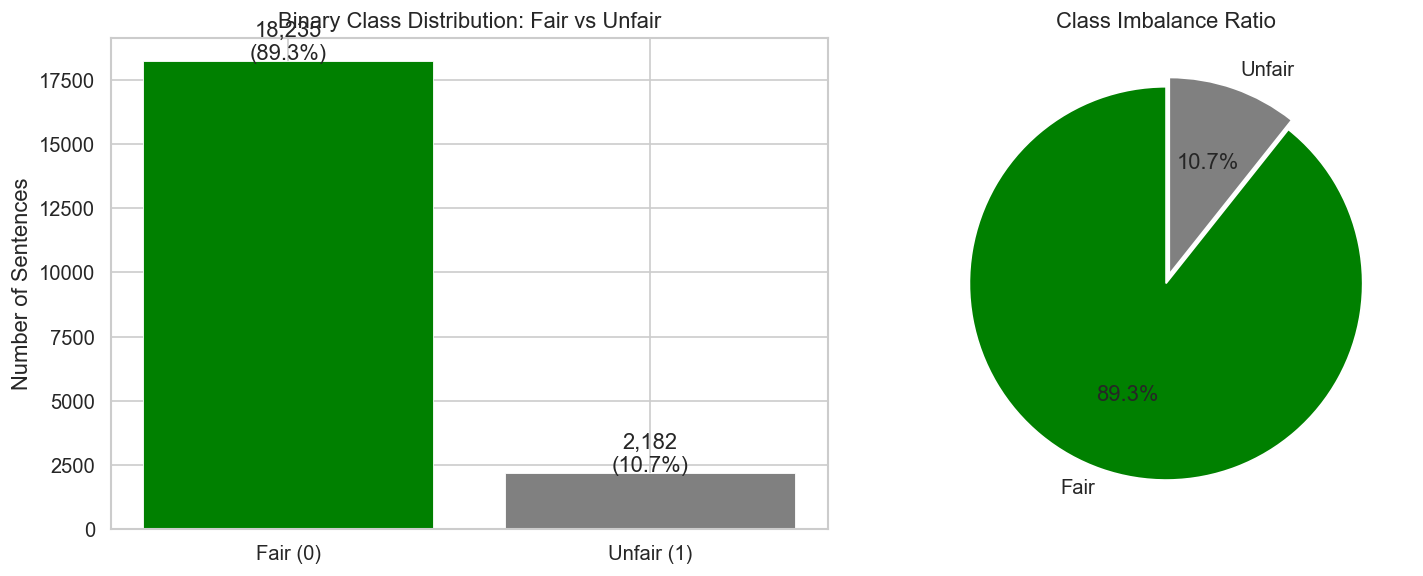


Imbalance ratio (Fair : Unfair) = 8.4 : 1


In [16]:
binary_counts = df['label'].value_counts().sort_index()
binary_pcts   = df['label'].value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
# Adapted from https://www.geeksforgeeks.org/python/stacked-percentage-bar-plot-in-matplotlib/
colours = ['green', 'grey']
bars = axes[0].bar(['Fair (0)', 'Unfair (1)'], binary_counts.values,
                    color=colours, linewidth=0.5)
for bar, count, pct in zip(bars, binary_counts.values, binary_pcts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}\n({pct:.1f}%)', ha='center')
axes[0].set_title('Binary Class Distribution: Fair vs Unfair')
axes[0].set_ylabel('Number of Sentences')

# Pie chart
# Adapted from https://www.geeksforgeeks.org/python/plot-a-pie-chart-in-python-using-matplotlib/
axes[1].pie(binary_counts.values, labels=['Fair', 'Unfair'], colors=colours,
            autopct='%1.1f%%', startangle=90, explode=(0, 0.05))
axes[1].set_title('Class Imbalance Ratio')

plt.tight_layout()
plt.savefig('binary_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

imbalance_ratio = binary_counts[0] / binary_counts[1]
print(f"\nImbalance ratio (Fair : Unfair) = {imbalance_ratio:.1f} : 1")

#### 4.2 Category Distribution (Multi-Label)

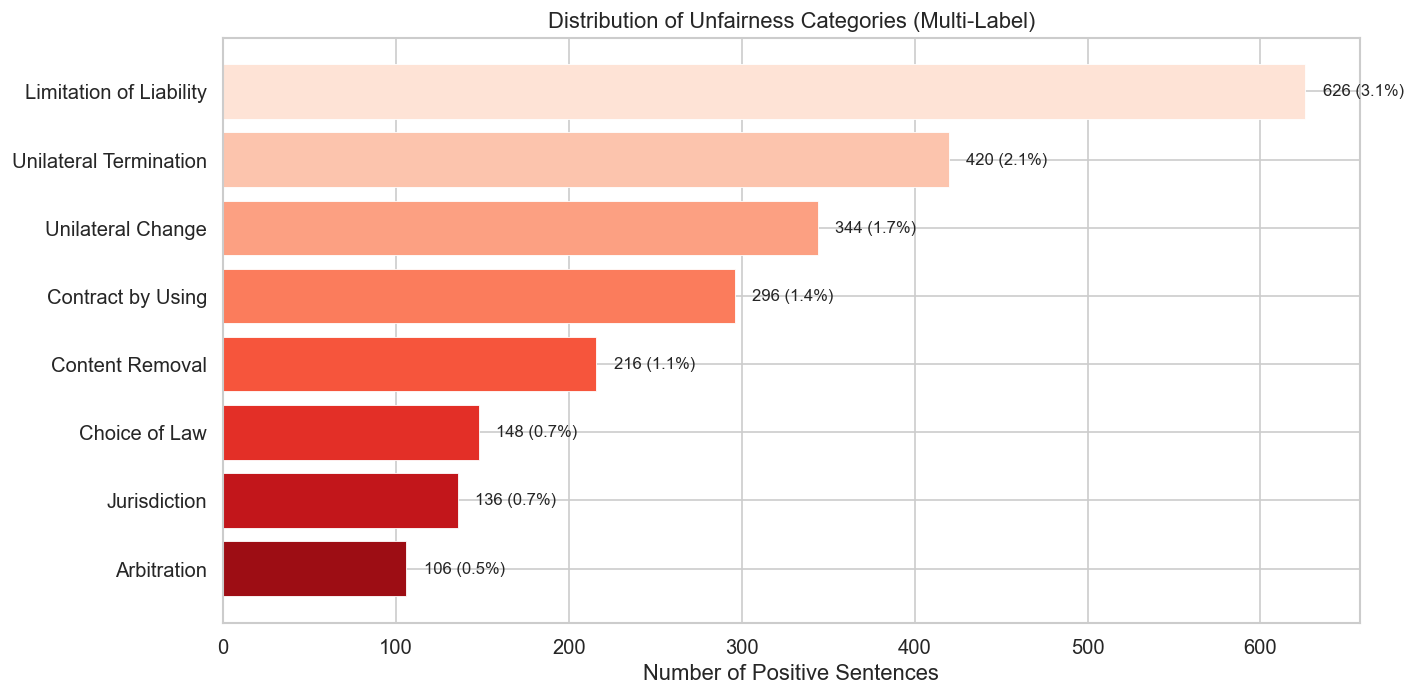

Key observation: severe class imbalance across all categories.
Most common:  Limitation of Liability — 626 (3.1%)
Least common: Arbitration — 106 (0.5%)


In [17]:
category_counts = {LABEL_NAMES[c]: df[c].sum() for c in LABEL_COLS}
category_counts = dict(sorted(category_counts.items(), key=lambda x: x[1]))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(list(category_counts.keys()), list(category_counts.values()),
               color=sns.color_palette('Reds_r', n_colors=8), linewidth=0.5)
# Adapted from https://www.geeksforgeeks.org/python/plot-a-pie-chart-in-python-using-matplotlib/
for bar, count in zip(bars, category_counts.values()):
    pct = count / len(df) * 100
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{count} ({pct:.1f}%)', va='center', fontsize=10)
ax.set_xlabel('Number of Positive Sentences')
ax.set_title('Distribution of Unfairness Categories (Multi-Label)')
plt.tight_layout()
plt.savefig('category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key observation: severe class imbalance across all categories.")
print(f"Most common:  Limitation of Liability — {df['LTD'].sum()} ({df['LTD'].mean()*100:.1f}%)")
print(f"Least common: Arbitration — {df['A'].sum()} ({df['A'].mean()*100:.1f}%)")

#### 4.3 Number of Unfair Labels per Sentence

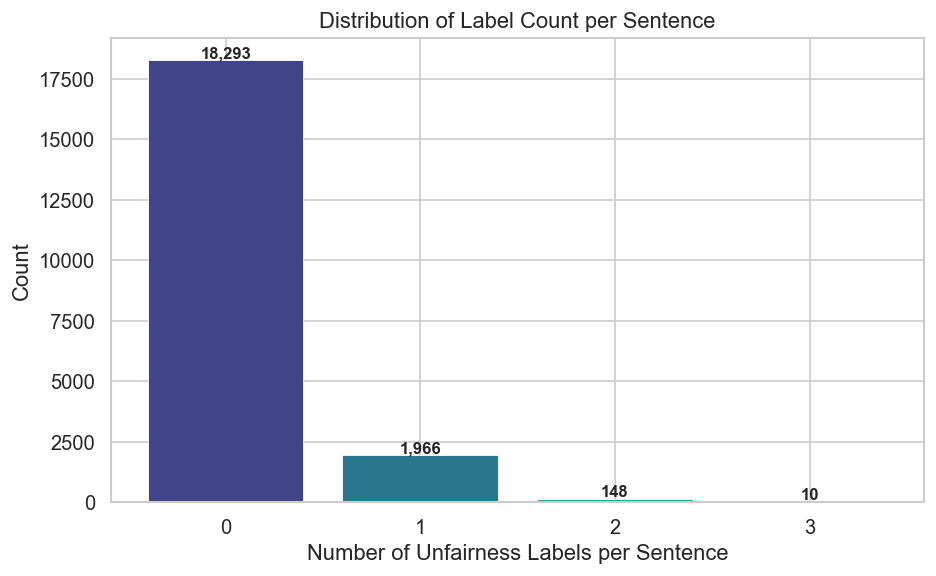

Sentences with 0 labels (fair): 18,293
Sentences with 1 label:         1,966
Sentences with 2+ labels:       158


In [18]:
#Counting all the labels per sentence
df['num_labels'] = df[LABEL_COLS].sum(axis=1)
label_count_dist = df['num_labels'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(label_count_dist.index, label_count_dist.values,
              color=sns.color_palette('viridis', n_colors=len(label_count_dist)),linewidth=0.5)
for bar, count in zip(bars, label_count_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{count:,}', ha='center', fontweight='bold', fontsize=10)
ax.set_xlabel('Number of Unfairness Labels per Sentence')
ax.set_ylabel('Count')
ax.set_title('Distribution of Label Count per Sentence')
ax.set_xticks(label_count_dist.index)
plt.tight_layout()
plt.savefig('labels_per_sentence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Sentences with 0 labels (fair): {label_count_dist.get(0, 0):,}")
print(f"Sentences with 1 label:         {label_count_dist.get(1, 0):,}")
print(f"Sentences with 2+ labels:       {df[df['num_labels'] >= 2].shape[0]:,}")

#### 4.4 Multi-label Classification Analysis(Heatmap)

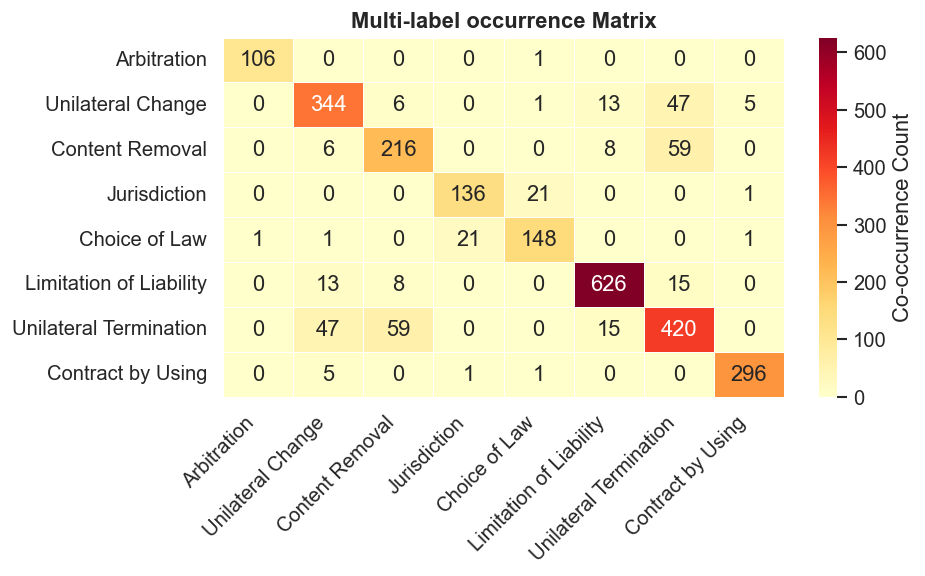

In [19]:
# multi-label occurrence matrix (only among unfair sentences)
cooccurrence = df[LABEL_COLS].T.dot(df[LABEL_COLS])
cooccurrence.index   = [LABEL_NAMES[c] for c in LABEL_COLS]
cooccurrence.columns = [LABEL_NAMES[c] for c in LABEL_COLS]
                        
fig, ax = plt.subplots(figsize=(8, 5))
# Adapted from https://www.geeksforgeeks.org/data-visualization/customizing-heatmap-colors-with-matplotlib/
sns.heatmap(cooccurrence, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Co-occurrence Count'})
ax.set_title('Multi-label occurrence Matrix', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('cooccurrence_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Text Length Distribution Analysis

In [20]:
df['word_count'] = df['text'].fillna('').apply(lambda x: len(x.split()))

print("Word count statistics by class:")
print(df.groupby('label')['word_count'].describe().round(1))
print()
print(f"Median word count(Fair):   {df[df['label']==0]['word_count'].median():.0f}")
print(f"Median word count(Unfair): {df[df['label']==1]['word_count'].median():.0f}")

Word count statistics by class:
         count  mean   std  min   25%   50%   75%    max
label                                                   
0      18235.0  31.1  23.3  6.0  17.0  26.0  38.0  310.0
1       2182.0  42.3  33.1  6.0  22.0  33.0  51.0  353.0

Median word count(Fair):   26
Median word count(Unfair): 33


#### 5.1 Overlapping histogram, for comparison

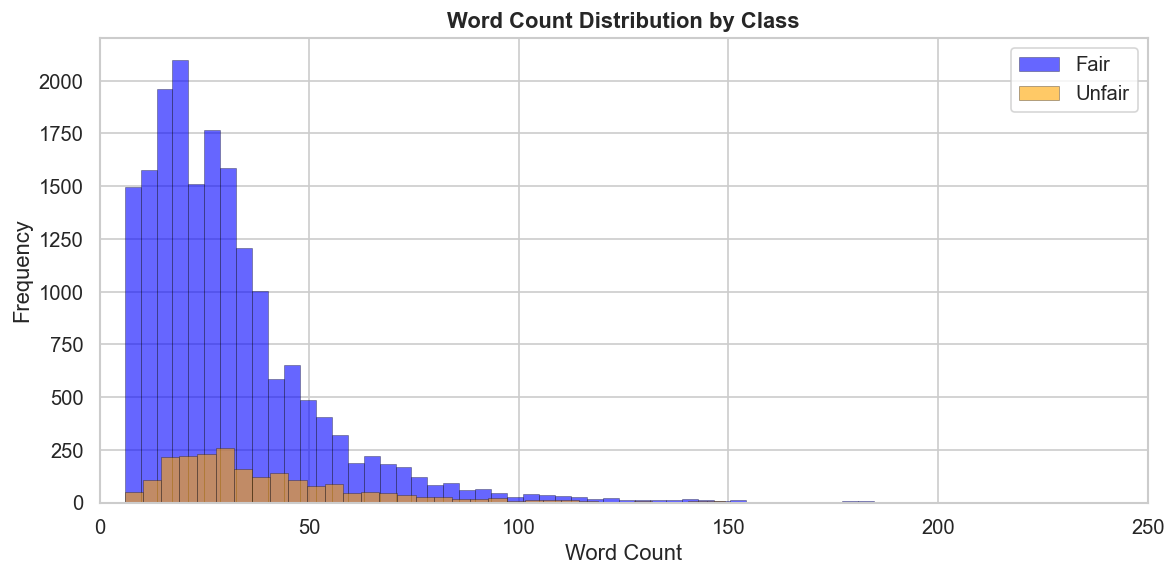

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
for label_val, colour, label_name in [(0, 'blue', 'Fair'), (1, 'orange', 'Unfair')]:
    subset = df[df['label'] == label_val]
    ax.hist(subset['word_count'], bins=80, alpha=0.6, color=colour,
            label=label_name, edgecolor='black', linewidth=0.3)
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.set_title('Word Count Distribution by Class', fontweight='bold')
ax.legend()
ax.set_xlim(0, 250)
plt.tight_layout()
plt.savefig('text_length_hist.png', dpi=150, bbox_inches='tight')
plt.show()

#### 5.2 Box plot

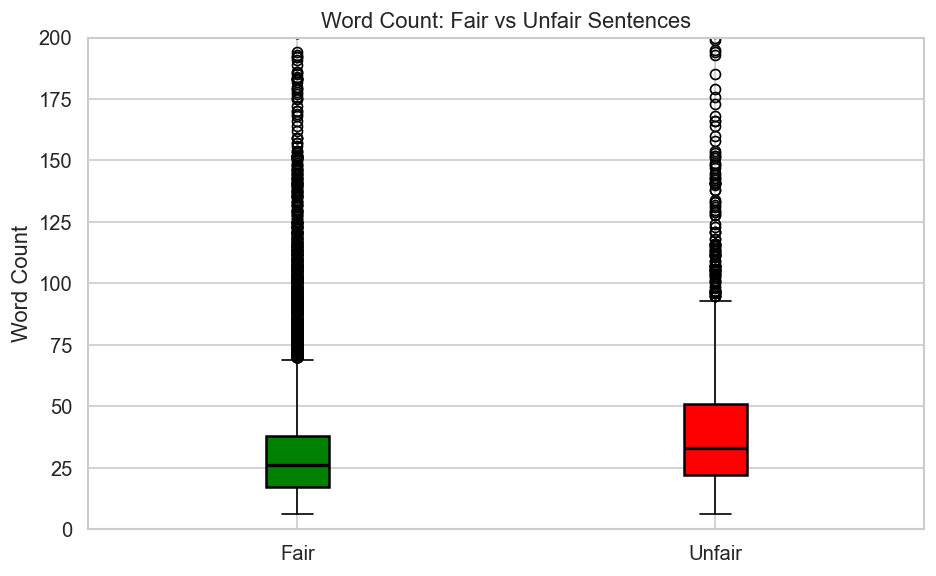

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
data_to_plot = [df[df['label'] == 0]['word_count'],
                df[df['label'] == 1]['word_count']]
bp = ax.boxplot(data_to_plot, labels=['Fair', 'Unfair'], patch_artist=True,
                boxprops=dict(linewidth=1.5),
                medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('green')
bp['boxes'][1].set_facecolor('red')
ax.set_ylabel('Word Count')
ax.set_title('Word Count: Fair vs Unfair Sentences')
ax.set_ylim(0, 200)
plt.tight_layout()
plt.savefig('boxplot_wordcount.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Word Clouds

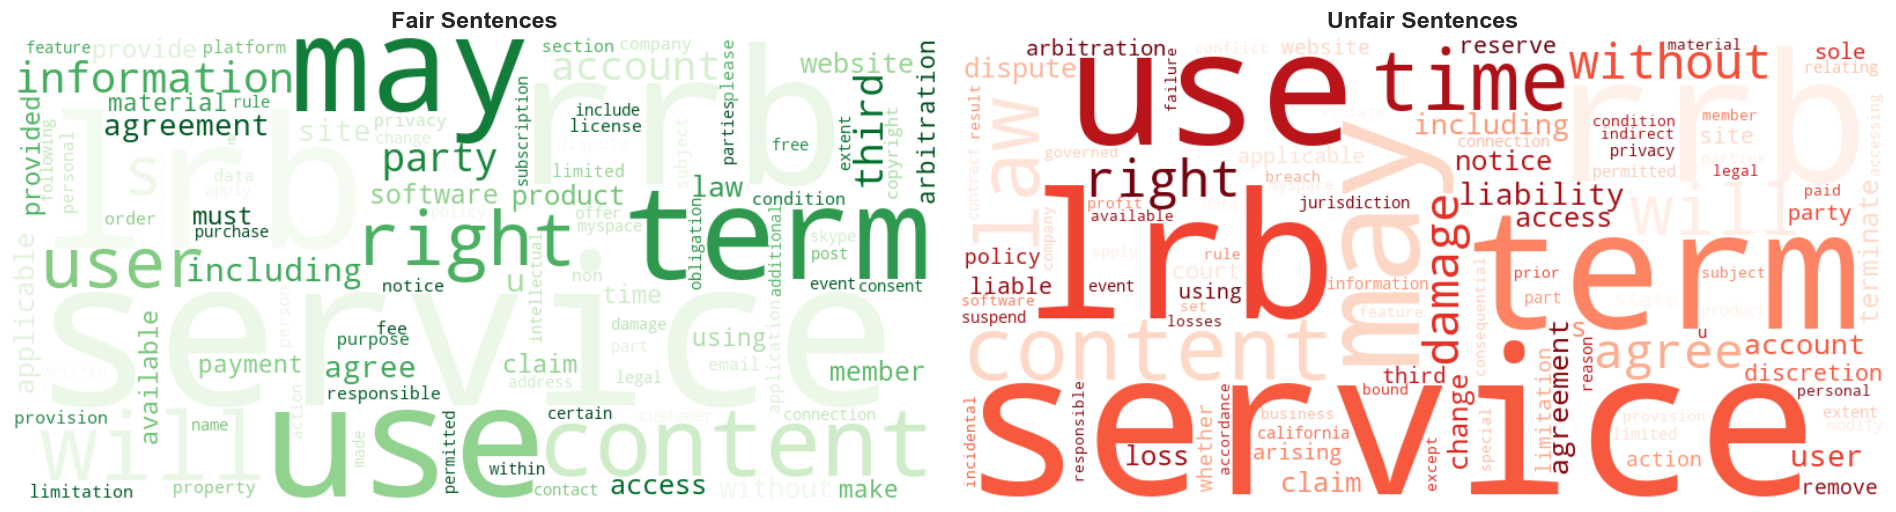

In [23]:
# Adapted from University of Hull (Applied AI, week 7 workshop).
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for idx, (label_val, title, cmap) in enumerate([
    (0, 'Fair Sentences', 'Greens'),
    (1, 'Unfair Sentences', 'Reds')
]):
    text = ' '.join(df[df['label'] == label_val]['text'].fillna('').tolist())
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=cmap, max_words=100, collocations=False,
                   random_state=42).generate(text)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(title, fontweight='bold', fontsize=14)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Document Level Analysis

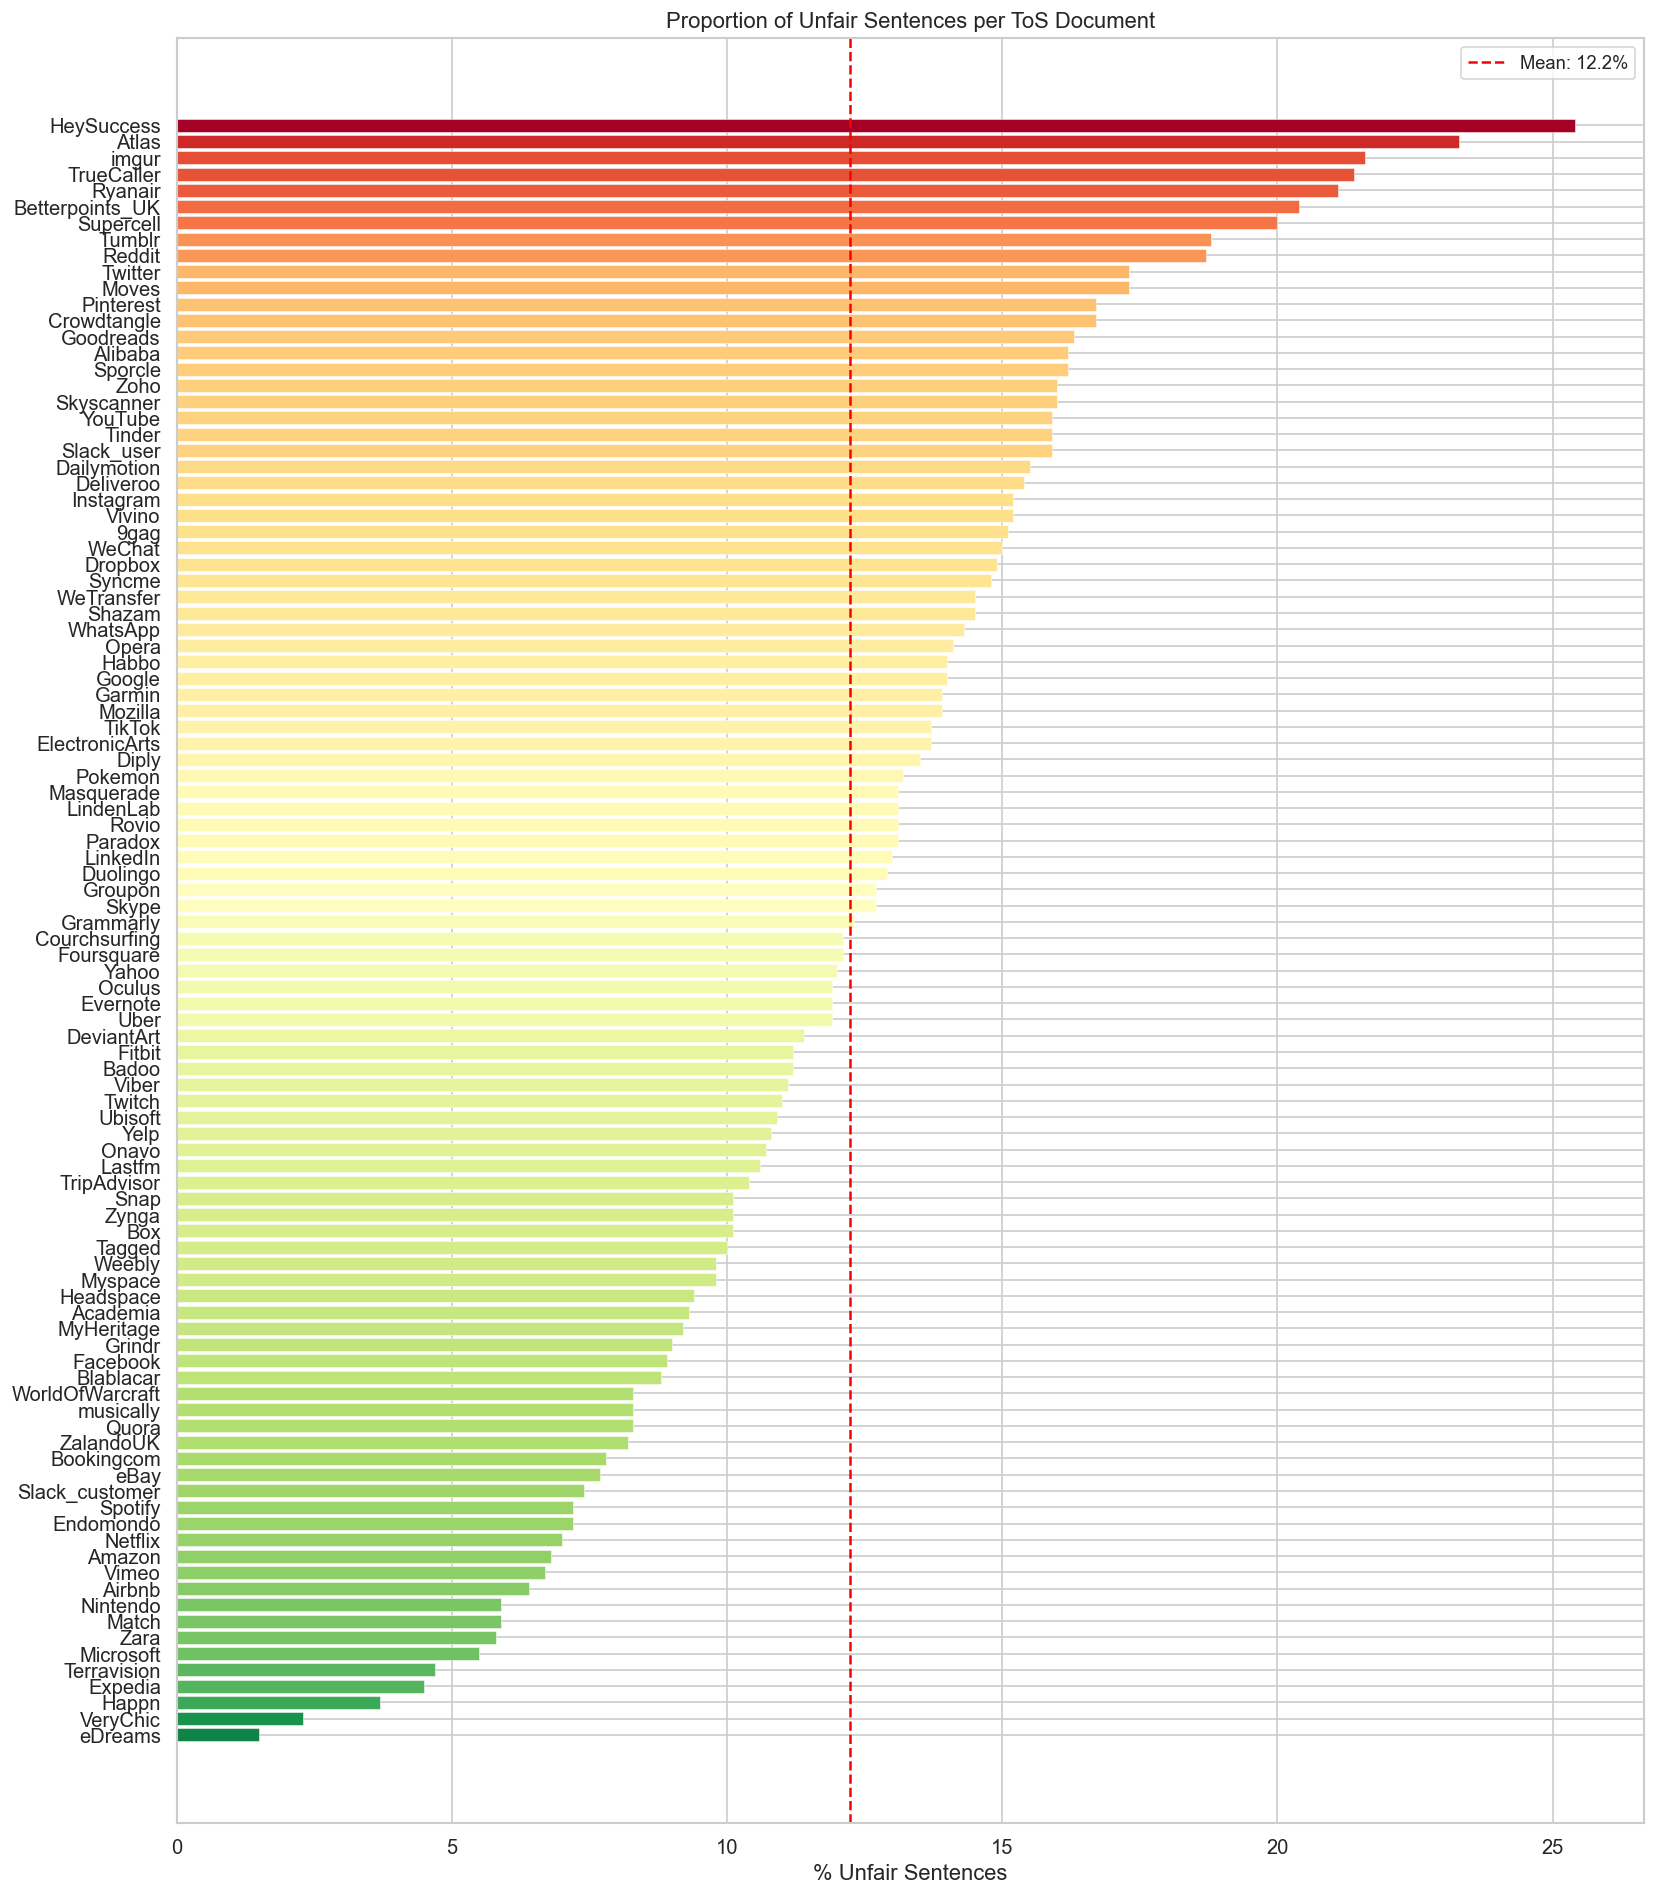


Mean unfairness rate across documents: 12.2%
Min:  1.5%  (eDreams)
Max:  25.4%  (HeySuccess)

Top 5 most unfair ToS documents:
  document  total_sentences  unfair_sentences  unfair_pct
HeySuccess              122                31        25.4
     Atlas               60                14        23.3
     imgur               74                16        21.6
TrueCaller               98                21        21.4
   Ryanair               19                 4        21.1


In [24]:
# Compute statistics per document 
doc_stats = df.groupby('document').agg(
    total_sentences=('label', 'count'),
    unfair_sentences=('label', 'sum'),
).reset_index()
doc_stats['unfair_pct'] = (doc_stats['unfair_sentences'] / doc_stats['total_sentences'] * 100).round(1)
doc_stats = doc_stats.sort_values('unfair_pct', ascending=True)

fig, ax = plt.subplots(figsize=(14, 16))
colours = plt.cm.RdYlGn_r(doc_stats['unfair_pct'] / doc_stats['unfair_pct'].max())
ax.barh(doc_stats['document'], doc_stats['unfair_pct'],
        color=colours, linewidth=0.3)
ax.set_xlabel('% Unfair Sentences')
ax.set_title('Proportion of Unfair Sentences per ToS Document')
mean_pct = doc_stats['unfair_pct'].mean()
# Adapted from https://www.geeksforgeeks.org/python/plot-a-horizontal-line-in-matplotlib/
# Adapted from https://www.geeksforgeeks.org/python/plot-a-vertical-line-in-matplotlib/
ax.axvline(x=mean_pct, color='red', linestyle='--', linewidth=1.5,
           label=f'Mean: {mean_pct:.1f}%')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('document_unfairness.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMean unfairness rate across documents: {mean_pct:.1f}%")
print(f"Min:  {doc_stats['unfair_pct'].min():.1f}%  ({doc_stats.iloc[0]['document']})")
print(f"Max:  {doc_stats['unfair_pct'].max():.1f}%  ({doc_stats.iloc[-1]['document']})")
print()
print("Top 5 most unfair ToS documents:")
print(doc_stats.nlargest(5, 'unfair_pct')[['document', 'total_sentences',
      'unfair_sentences', 'unfair_pct']].to_string(index=False))

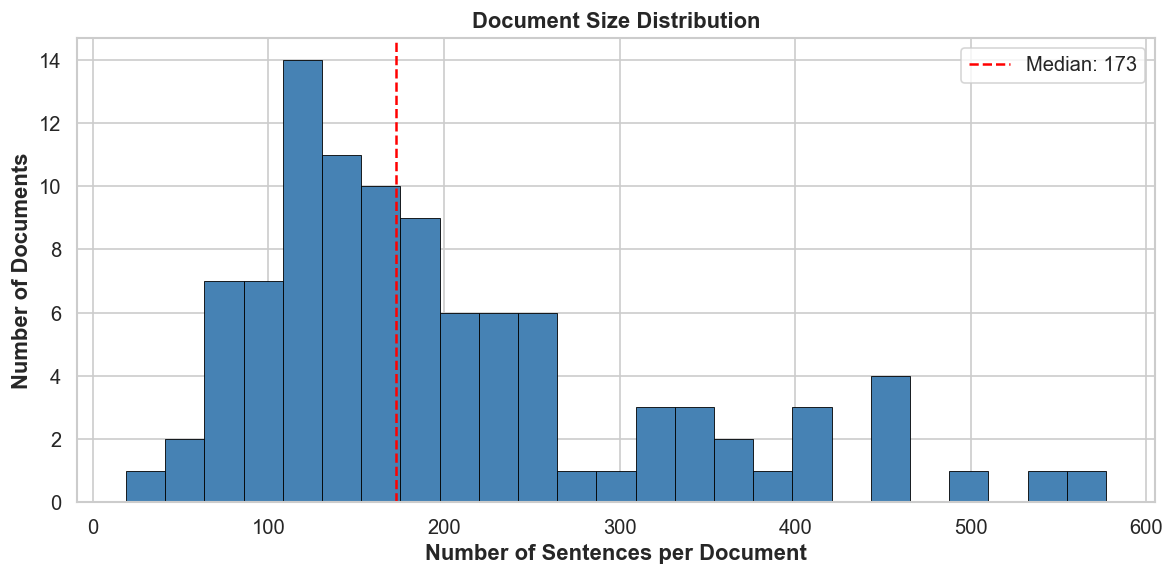

In [25]:
# sentence count distribution per document 
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(doc_stats['total_sentences'], bins=25, color='steelblue',
        edgecolor='black', linewidth=0.5)
ax.set_xlabel('Number of Sentences per Document', fontweight='bold')
ax.set_ylabel('Number of Documents', fontweight='bold')
ax.set_title('Document Size Distribution', fontweight='bold')
ax.axvline(doc_stats['total_sentences'].median(), color='red', linestyle='--',
           label=f"Median: {doc_stats['total_sentences'].median():.0f}")
ax.legend()
plt.tight_layout()
plt.savefig('document_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Document Level Train / Validation / Test Split

The data is split at **document level** rather than the sentence level because it helps to prevent data leakage. Hence, sentences from the same ToS document will not appear in both training and test sets. This is important because sentences within a single ToS share vocabulary and legal phrasing.

The data is split as 80/10/10 by document count.

In [26]:
documents = df['document'].unique()
np.random.seed(42)
np.random.shuffle(documents)

n = len(documents)
n_train = int(0.8 * n)  # 80 documents
n_val   = int(0.1 * n)  # 10 documents

train_docs = documents[:n_train]
val_docs   = documents[n_train:n_train + n_val]
test_docs  = documents[n_train + n_val:]

df_train = df[df['document'].isin(train_docs)].copy()
df_val   = df[df['document'].isin(val_docs)].copy()
df_test  = df[df['document'].isin(test_docs)].copy()

print("Document split:")
print(f"{'Split':<12} {'Docs':>5} {'Sentences':>10} {'Unfair':>8} {'% Unfair':>10}")
for name, frame in [('Train', df_train), ('Validation', df_val), ('Test', df_test)]:
    n_unfair = frame['label'].sum()
    pct = frame['label'].mean() * 100
    print(f"{name:<12} {frame['document'].nunique():>5} {len(frame):>10,} {n_unfair:>8} {pct:>9.1f}%")

print(f"\nTotal: {len(df_train)+len(df_val)+len(df_test):,} sentences")

Document split:
Split         Docs  Sentences   Unfair   % Unfair
Train           80     16,493     1701      10.3%
Validation      10      2,044      240      11.7%
Test            10      1,880      241      12.8%

Total: 20,417 sentences


## 9. Baseline: Majority Class Classifier

A majority class classifier always predicts the most frequent class. Since ~89% of sentences are fair, this baseline always predicts "0" (fair). It provides a lower bound to which other models should improve. 

In [27]:
y_test  = df_test['label'].values
y_pred_majority = np.zeros_like(y_test)

print("MAJORITY CLASS BASELINE (always predict Fair)")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_majority):.4f}")
print(f"  Macro F1 : {f1_score(y_test, y_pred_majority, average='macro'):.4f}")
print(f"  Micro F1 : {f1_score(y_test, y_pred_majority, average='micro'):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_majority, target_names=['Fair', 'Unfair']))

MAJORITY CLASS BASELINE (always predict Fair)
  Accuracy : 0.8718
  Macro F1 : 0.4658
  Micro F1 : 0.8718

Classification Report:
              precision    recall  f1-score   support

        Fair       0.87      1.00      0.93      1639
      Unfair       0.00      0.00      0.00       241

    accuracy                           0.87      1880
   macro avg       0.44      0.50      0.47      1880
weighted avg       0.76      0.87      0.81      1880



**Why accuracy is misleading:** The majority class baseline achieves ~89% accuracy by predicting every sentence as fair. However, it has **0% recall on the unfair class**, i.e., it misses every unfair clause, which defeats the purpose of the system. Hence, **macro averaged F1** is used as the primary metric, since it weights both classes equally regardless of size.

## 10. Text Preprocessing

#### 10.1 Text Cleaning

In [28]:
!python -m spacy download en_core_web_sm

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 8.9 MB/s eta 0:00:02
     ----------- ---------------------------- 3.7/12.8 MB 14.8 MB/s eta 0:00:01
     --------------------------------------  12.6/12.8 MB 28.3 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 26.6 MB/s  0:00:00
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [29]:
# Basic text cleaning before tokenisation
# Adapted from University of Hull (Applied AI week 7 workshop)
def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text).lower()
    # Replacing legal bracket tokens
    text = text.replace('-lrb-', '(').replace('-rrb-', ')')
    text = text.replace('-lsb-', '[').replace('-rsb-', ']')
    # Removing punctuation
    text = re.sub(r'[,\.?!;:\'\"()\[\]]', '', text)
    # Removing whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning to all splits
for frame in [df_train, df_val, df_test]:
    frame['clean_text'] = frame['text'].apply(clean_text)

# Show before/after
print("Before and After Cleaning:")
for _, row in df_train.sample(3, random_state=99).iterrows():
    print(f"  Original: {row['text'][:120].strip()}")
    print(f"  Cleaned : {row['clean_text'][:120]}")
    print()

Before and After Cleaning:
  Original: arbitrations have different rules than lawsuits in court .
  Cleaned : arbitrations have different rules than lawsuits in court

  Original: k -rrb- references to `` clauses '' are to clauses of these terms and conditions ;
  Cleaned : k references to `` clauses are to clauses of these terms and conditions

  Original: registration to the services is free .
  Cleaned : registration to the services is free



#### 10.2 Tokenisation with gensim

In [30]:
# Adapted from University of Hull (Applied AI week 7 workshop) 
def sent_to_words(sentences):
    for sentence in sentences:
        yield(simple_preprocess(sentence, deacc=False))

# Tokenise training data
train_data_words = list(sent_to_words(df_train['clean_text']))
val_data_words   = list(sent_to_words(df_val['clean_text']))
test_data_words  = list(sent_to_words(df_test['clean_text']))

print(f"Sample tokenised sentence:")
print(f"  {train_data_words[0][:15]}...")

Sample tokenised sentence:
  ['websites', 'communications', 'terms', 'of', 'use']...


#### 10.3 Stopword Removal 

In [31]:
# Using gensim's STOPWORDS 
# Adapted from University of Hull (Applied AI week 7 workshop)
stop_words = STOPWORDS.union(set(['lrb', 'rrb', 'lsb', 'rsb', 'br']))

def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc))
             if word not in stop_words] for doc in texts]

train_no_stops = remove_stopwords(train_data_words)
val_no_stops   = remove_stopwords(val_data_words)
test_no_stops  = remove_stopwords(test_data_words)

print(f"Before stopword removal: {len(train_data_words[0])} tokens")
print(f"After stopword removal:  {len(train_no_stops[0])} tokens")

Before stopword removal: 5 tokens
After stopword removal:  4 tokens


#### 10.4 Biagram Detection 

In [32]:
# Build bigram model from training data
#Adapted from University of Hull (Applied AI week 7 workshop)
bigram = gensim.models.phrases.Phrases(train_no_stops, min_count=5, threshold=100)
bigram_mod = gensim.models.phrases.Phraser(bigram)

def make_bigrams(texts):
    return [bigram_mod[doc] for doc in texts]

train_bigrams = make_bigrams(train_no_stops)
val_bigrams   = make_bigrams(val_no_stops)
test_bigrams  = make_bigrams(test_no_stops)

# Show detected bigrams
print("Detected bigrams in training data:")
for bg in list(bigram_mod.phrasegrams.keys())[:15]:
    print(f"  {bg}")

Detected bigrams in training data:
  social_media
  source_code
  add_ons
  trade_dress
  open_source
  represent_warrant
  nonexclusive_royalty
  royalty_free
  online_offline
  intellectual_property
  email_addresses
  suspend_terminate
  defend_indemnify
  indemnify_hold
  hold_harmless


#### 10.5 Lemmatisation with spaCy

In [33]:
nlp = spacy.load("en_core_web_sm")

In [34]:
# Adapted from University of Hull (Applied AI week 7 workshop)
def lemmatization(texts, allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV', 'AUX']):
    """Lemmatise tokens using spaCy, keeping only specified POS tags."""
    texts_out = []
    for sent in texts:
        doc = nlp(" ".join(sent))
        texts_out.append([token.lemma_ for token in doc
                          if token.pos_ in allowed_postags])
    return texts_out
train_lemmatized = lemmatization(train_bigrams)
val_lemmatized   = lemmatization(val_bigrams)
test_lemmatized  = lemmatization(test_bigrams)

print(f"\nSample lemmatised sentence:")
print(f"  {train_lemmatized[0][:15]}")


Sample lemmatised sentence:
  ['website', 'communication', 'term', 'use']


In [35]:
# Convert lemmatised token lists back to strings for vectorisation
train_strings = [' '.join(tokens) for tokens in train_lemmatized]
val_strings   = [' '.join(tokens) for tokens in val_lemmatized]
test_strings  = [' '.join(tokens) for tokens in test_lemmatized]

print(f"Sample preprocessed string:")
print(f"  \"{train_strings[0][:150]}\"")

Sample preprocessed string:
  "website communication term use"


#### 10.6 TF-IDF Vectorisation

In [36]:
# Build TF-IDF pipeline (CountVectorizer + TfidfTransformer)
tfidf_pipeline = Pipeline([
    ("vect", CountVectorizer(max_features=10000, ngram_range=(1, 2),
                             min_df=2, max_df=0.95)),
    ("tfidf", TfidfTransformer(sublinear_tf=True)),
])
X_train_tfidf = tfidf_pipeline.fit_transform(train_strings)
X_val_tfidf   = tfidf_pipeline.transform(val_strings)
X_test_tfidf  = tfidf_pipeline.transform(test_strings)

y_train = df_train['label'].values
y_val   = df_val['label'].values
y_test  = df_test['label'].values

print(f"TF-IDF matrix shapes:")
print(f"  Train:      {X_train_tfidf.shape}")
print(f"  Validation: {X_val_tfidf.shape}")
print(f"  Test:       {X_test_tfidf.shape}")

TF-IDF matrix shapes:
  Train:      (16493, 10000)
  Validation: (2044, 10000)
  Test:       (1880, 10000)


#### 10.7 Handling Class Imbalance

In [37]:
classes = np.array([0, 1])
class_weights_array = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = {0: class_weights_array[0], 1: class_weights_array[1]}

print("Computed class weights:")
print(f"  Fair (0)  : {class_weight_dict[0]:.4f}")
print(f"  Unfair (1): {class_weight_dict[1]:.4f}")
print(f"\nThe unfair class receives ~{class_weight_dict[1]/class_weight_dict[0]:.1f}x more weight.")

Computed class weights:
  Fair (0)  : 0.5575
  Unfair (1): 4.8480

The unfair class receives ~8.7x more weight.


## 11. 1st Traditional ML Model (Multinomial Naive Bayes)

Test Set Results
  Accuracy  : 0.90
  Macro F1  : 0.69
  Precision : 0.82
  Recall    : 0.29
  ROC-AUC   : 0.91

              precision    recall  f1-score   support

        Fair       0.91      0.99      0.95      1639
      Unfair       0.82      0.29      0.43       241

    accuracy                           0.90      1880
   macro avg       0.86      0.64      0.69      1880
weighted avg       0.89      0.90      0.88      1880



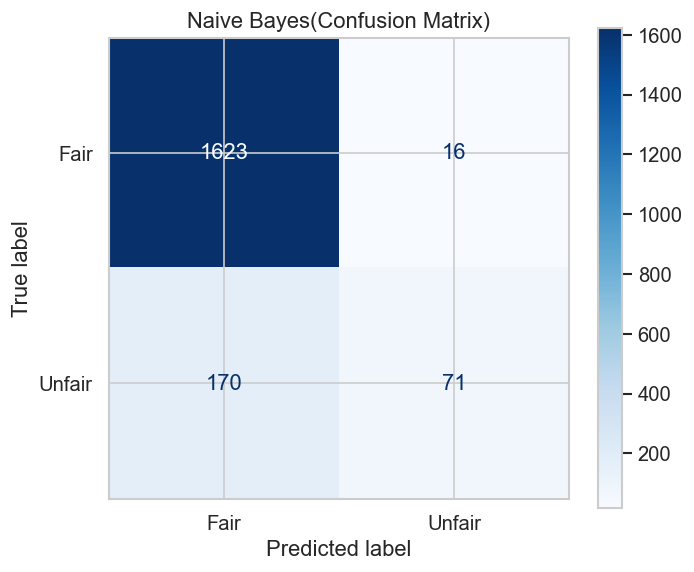

In [38]:
# aplha = 1.0 prevents zero probabilities by smoothing unseen features, ensuring the model still makes valid predictions
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb_test  = nb_model.predict(X_test_tfidf)
y_proba_nb_test = nb_model.predict_proba(X_test_tfidf)[:, 1]

print("Test Set Results")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_nb_test):.2f}")
print(f"  Macro F1  : {f1_score(y_test, y_pred_nb_test, average='macro'):.2f}")
print(f"  Precision : {precision_score(y_test, y_pred_nb_test, zero_division=0):.2f}")
print(f"  Recall    : {recall_score(y_test, y_pred_nb_test, zero_division=0):.2f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_proba_nb_test):.2f}")
print()
print(classification_report(y_test, y_pred_nb_test, target_names=['Fair', 'Unfair']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_nb_test),
                       display_labels=['Fair', 'Unfair']).plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Naive Bayes(Confusion Matrix)')
plt.tight_layout()
plt.savefig('naive_bayes_conf.png', dpi=150, bbox_inches='tight')
plt.show()
#Creating a dictionary to store all the models scores to be compared at the end of this notebook 
results = {}
results['Naive Bayes'] = {
    'Accuracy':  accuracy_score(y_test, y_pred_nb_test),
    'Macro F1':  f1_score(y_test, y_pred_nb_test, average='macro'),
    'F1 Fair':   f1_score(y_test, y_pred_nb_test, average='binary', pos_label=0),
    'F1 Unfair': f1_score(y_test, y_pred_nb_test, average='binary', pos_label=1),
    'ROC-AUC':   roc_auc_score(y_test, y_proba_nb_test)
}

## 12. 2nd Traditional ML Model 2 (Support Vector Machine (SVM))

In [39]:
# Hyperparameter tuning via GridSearchCV
param_grid = {'C': [0.01, 0.1, 1.0, 10.0]}
svm_base = LinearSVC(class_weight='balanced', max_iter=10000, random_state=42)
grid_search = GridSearchCV(svm_base, param_grid, cv=3, scoring='f1_macro',
                           verbose=1, n_jobs=-1)
grid_search.fit(X_train_tfidf, y_train)

cv_results = pd.DataFrame(grid_search.cv_results_)
print(f"Best C: {grid_search.best_params_['C']}")
print(f"Best CV Macro F1: {grid_search.best_score_:.4f}")
print()
print("Grid Search Results:")
print(cv_results[['param_C', 'mean_test_score', 'std_test_score']].to_string(index=False))

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best C: 1.0
Best CV Macro F1: 0.7866

Grid Search Results:
 param_C  mean_test_score  std_test_score
    0.01         0.757339        0.014841
    0.10         0.786137        0.015234
    1.00         0.786582        0.004370
   10.00         0.767242        0.006323


SVM (Tuned) Test Set Results
  Accuracy  : 0.93
  Macro F1  : 0.82
  Precision : 0.78
  Recall    : 0.60
  ROC-AUC   : 0.94

              precision    recall  f1-score   support

        Fair       0.94      0.97      0.96      1639
      Unfair       0.78      0.60      0.68       241

    accuracy                           0.93      1880
   macro avg       0.86      0.79      0.82      1880
weighted avg       0.92      0.93      0.92      1880



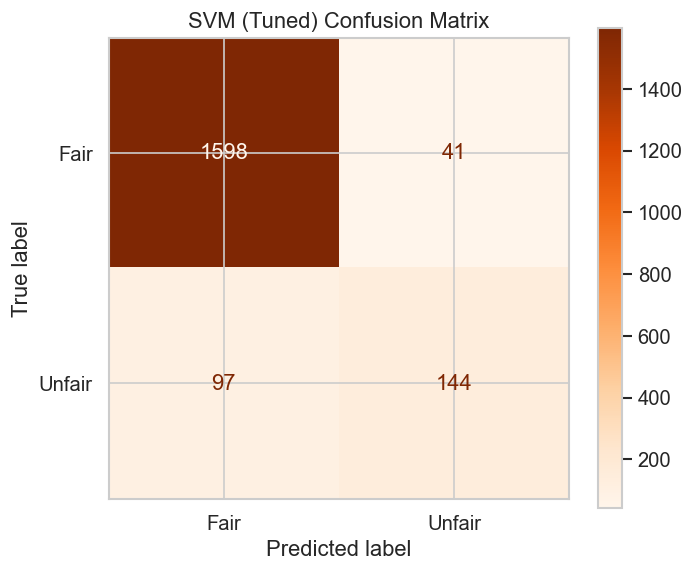

In [40]:
# Final SVM with calibrated probabilities
best_svm = LinearSVC(C=grid_search.best_params_['C'],
                     class_weight='balanced', max_iter=10000, random_state=42)
svm_calibrated = CalibratedClassifierCV(best_svm, cv=3)
svm_calibrated.fit(X_train_tfidf, y_train)

y_pred_svm_test  = svm_calibrated.predict(X_test_tfidf)
y_proba_svm_test = svm_calibrated.predict_proba(X_test_tfidf)[:, 1]

print("SVM (Tuned) Test Set Results")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_svm_test):.2f}")
print(f"  Macro F1  : {f1_score(y_test, y_pred_svm_test, average='macro'):.2f}")
print(f"  Precision : {precision_score(y_test, y_pred_svm_test):.2f}")
print(f"  Recall    : {recall_score(y_test, y_pred_svm_test):.2f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_proba_svm_test):.2f}")
print()
print(classification_report(y_test, y_pred_svm_test, target_names=['Fair', 'Unfair']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_svm_test),
                       display_labels=['Fair', 'Unfair']).plot(ax=ax, cmap='Oranges', values_format='d')
ax.set_title('SVM (Tuned) Confusion Matrix')
plt.tight_layout()
plt.savefig('svm_conf.png', dpi=150, bbox_inches='tight')
plt.show()

results['SVM'] = {
    'Accuracy':  accuracy_score(y_test, y_pred_svm_test),
    'Macro F1':  f1_score(y_test, y_pred_svm_test, average='macro'),
    'F1 Fair':   f1_score(y_test, y_pred_svm_test, average='binary', pos_label=0),
    'F1 Unfair': f1_score(y_test, y_pred_svm_test, average='binary', pos_label=1),
    'ROC-AUC':   roc_auc_score(y_test, y_proba_svm_test)
}

## 13. 1st Deep Learning Model 1, Bidirectional LSTM (Keras)

In [41]:
# Tokenise using Keras tokeniser on cleaned text (but not lemmatised)
# Adapted from https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/
MAX_VOCAB = 15000 #Maximum vocab size 
MAX_LEN   = 128 #sequence length

tokenizer_keras = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer_keras.fit_on_texts(df_train['clean_text'].values)

X_train_seq = tokenizer_keras.texts_to_sequences(df_train['clean_text'].values)
X_val_seq   = tokenizer_keras.texts_to_sequences(df_val['clean_text'].values)
X_test_seq  = tokenizer_keras.texts_to_sequences(df_test['clean_text'].values)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Vocabulary size: {min(MAX_VOCAB, len(tokenizer_keras.word_index)+1):,}")
print(f"Padded shape (train): {X_train_pad.shape}")

Vocabulary size: 9,600
Padded shape (train): (16493, 128)


In [42]:
# Adapted from https://keras.io/api/layers/recurrent_layers/bidirectional/
EMBEDDING_DIM = 64

def build_lstm_model():
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
        Bidirectional(LSTM(64, return_sequences=False, dropout=0.3, recurrent_dropout=0.3)),
        Dropout(0.4),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

lstm_model = build_lstm_model()
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [43]:
early_stop = EarlyStopping(monitor='val_loss', patience=3,
                           restore_best_weights=True, verbose=1)

history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15, batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop], verbose=1
)

Epoch 1/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 59s 104ms/step - accuracy: 0.6289 - loss: 0.5814 - val_accuracy: 0.8356 - val_loss: 0.4333
Epoch 2/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 51s 98ms/step - accuracy: 0.8889 - loss: 0.3170 - val_accuracy: 0.8659 - val_loss: 0.3467
Epoch 3/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 51s 100ms/step - accuracy: 0.9147 - loss: 0.2446 - val_accuracy: 0.8341 - val_loss: 0.4319
Epoch 4/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 51s 99ms/step - accuracy: 0.9174 - loss: 0.2082 - val_accuracy: 0.8332 - val_loss: 0.3992
Epoch 5/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 52s 100ms/step - accuracy: 0.9269 - loss: 0.1704 - val_accuracy: 0.8263 - val_loss: 0.4471
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


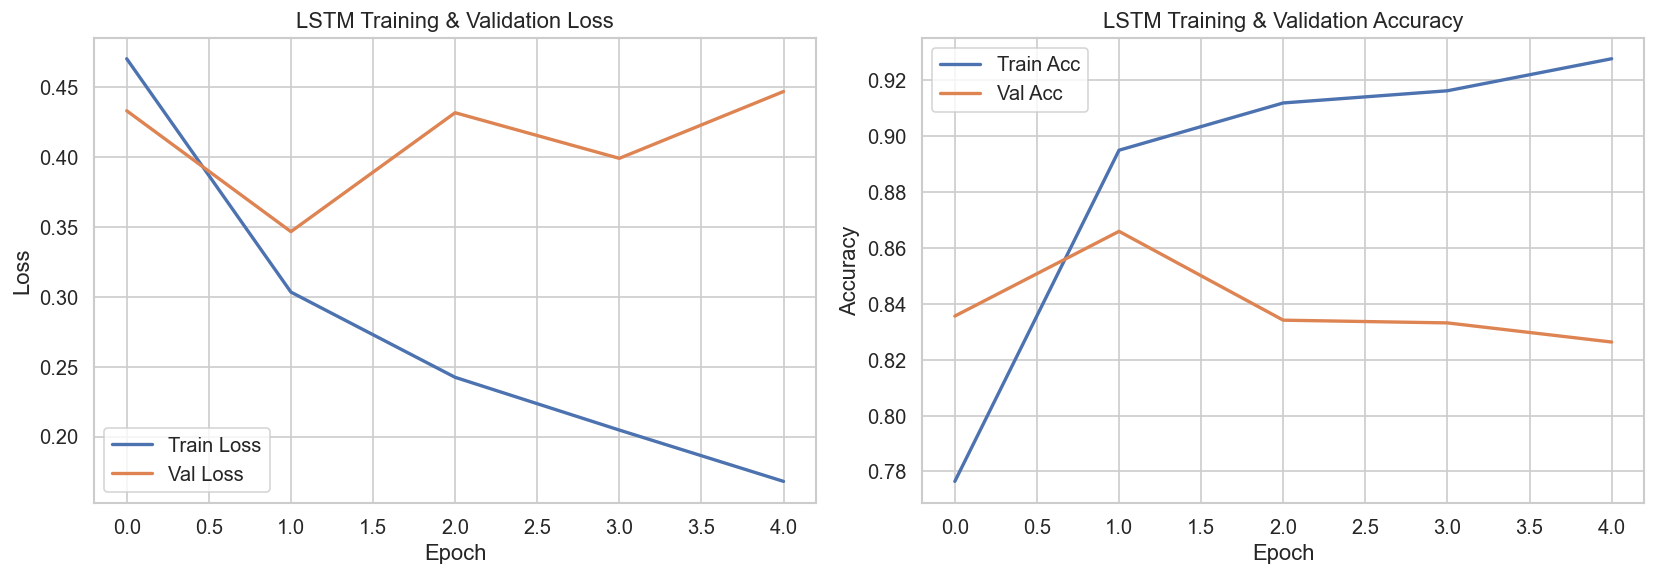

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_lstm.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_lstm.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('LSTM Training & Validation Loss'); axes[0].legend()

axes[1].plot(history_lstm.history['accuracy'], label='Train Acc', linewidth=2)
axes[1].plot(history_lstm.history['val_accuracy'], label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('LSTM Training & Validation Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step
LSTM (Test Set Results)
  Accuracy  : 0.86
  Macro F1  : 0.77
  Precision : 0.47
  Recall    : 0.90
  ROC-AUC   : 0.94

              precision    recall  f1-score   support

        Fair       0.98      0.85      0.91      1639
      Unfair       0.47      0.90      0.62       241

    accuracy                           0.86      1880
   macro avg       0.73      0.87      0.77      1880
weighted avg       0.92      0.86      0.87      1880



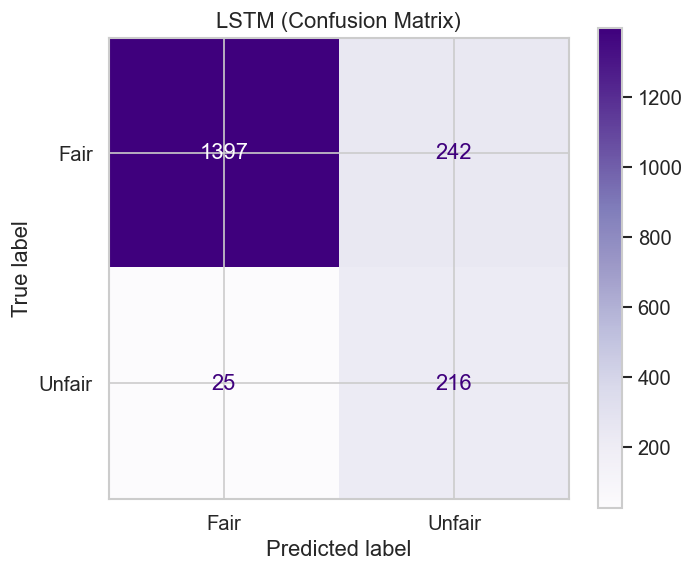

In [45]:
y_proba_lstm_test = lstm_model.predict(X_test_pad).flatten()
y_pred_lstm_test  = (y_proba_lstm_test >= 0.5).astype(int)

print("LSTM (Test Set Results)")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_lstm_test):.2f}")
print(f"  Macro F1  : {f1_score(y_test, y_pred_lstm_test, average='macro'):.2f}")
print(f"  Precision : {precision_score(y_test, y_pred_lstm_test):.2f}")
print(f"  Recall    : {recall_score(y_test, y_pred_lstm_test):.2f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_proba_lstm_test):.2f}")
print()
print(classification_report(y_test, y_pred_lstm_test, target_names=['Fair', 'Unfair']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lstm_test),
                       display_labels=['Fair', 'Unfair']).plot(ax=ax, cmap='Purples', values_format='d')
ax.set_title('LSTM (Confusion Matrix)')
plt.tight_layout()
plt.savefig('lstm_conf.png', dpi=150, bbox_inches='tight')
plt.show()

results['LSTM'] = {
    'Accuracy':  accuracy_score(y_test, y_pred_lstm_test),
    'Macro F1':  f1_score(y_test, y_pred_lstm_test, average='macro'),
    'F1 Fair':   f1_score(y_test, y_pred_lstm_test, average='binary', pos_label=0),
    'F1 Unfair': f1_score(y_test, y_pred_lstm_test, average='binary', pos_label=1),
    'ROC-AUC':   roc_auc_score(y_test, y_proba_lstm_test)
}

## 14. Deep Learning Model 2, BERT (Fine-Tuned, PyTorch)

In [46]:
# Tokenise with BERT tokeniser
# Adapted from https://www.tensorflow.org/text/tutorials/classify_text_with_bert#choose_a_bert_model_to_fine-tune
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
BERT_MAX_LEN = 128

train_encodings = bert_tokenizer(df_train['text'].tolist(), max_length=BERT_MAX_LEN,
                                  truncation=True, padding='max_length', return_tensors='pt')
val_encodings = bert_tokenizer(df_val['text'].tolist(), max_length=BERT_MAX_LEN,
                                truncation=True, padding='max_length', return_tensors='pt')
test_encodings = bert_tokenizer(df_test['text'].tolist(), max_length=BERT_MAX_LEN,
                                 truncation=True, padding='max_length', return_tensors='pt')
print(f"Done. Train input_ids shape: {train_encodings['input_ids'].shape}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Done. Train input_ids shape: torch.Size([16493, 128])


In [47]:
# PyTorch Dataset for BERT
class BertDataset(TorchDataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': self.labels[idx]
        }

train_dataset = BertDataset(train_encodings, y_train)
val_dataset   = BertDataset(val_encodings, y_val)
test_dataset  = BertDataset(test_encodings, y_test)

#reducing training dataset to reduce training time(trade-off)
train_dataset = torch.utils.data.Subset(train_dataset, range(0,  len(train_dataset)//2))

print(f"Datasets created: {len(train_dataset)} train, {len(val_dataset)} val, {len(test_dataset)} test")

Datasets created: 8246 train, 2044 val, 1880 test


In [48]:
# Loading BERT and defining training arguments
bert_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

training_args = TrainingArguments(
    output_dir='./bert_results',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',       # evaluate at the end of each epoch
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    seed=42,
    logging_steps=50,
)

# Custom metric function for Trainer
from sklearn.metrics import f1_score as sklearn_f1

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': sklearn_f1(labels, preds, average='macro'),
    }

# Custom Trainer with class-weighted loss
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        weight = torch.tensor([class_weight_dict[0], class_weight_dict[1]],
                              dtype=torch.float).to(logits.device)
        loss_fn = torch.nn.CrossEntropyLoss(weight=weight)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

trainer = WeightedTrainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("BERT model and Trainer ready.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model and Trainer ready.


In [49]:
# Train BERT
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.455365,0.443480,0.928082,0.816820
2,0.205034,0.367713,0.927593,0.842600


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1032, training_loss=0.39587466199268667, metrics={'train_runtime': 7449.6969, 'train_samples_per_second': 2.214, 'train_steps_per_second': 0.139, 'total_flos': 1084806881249280.0, 'train_loss': 0.39587466199268667, 'epoch': 2.0})

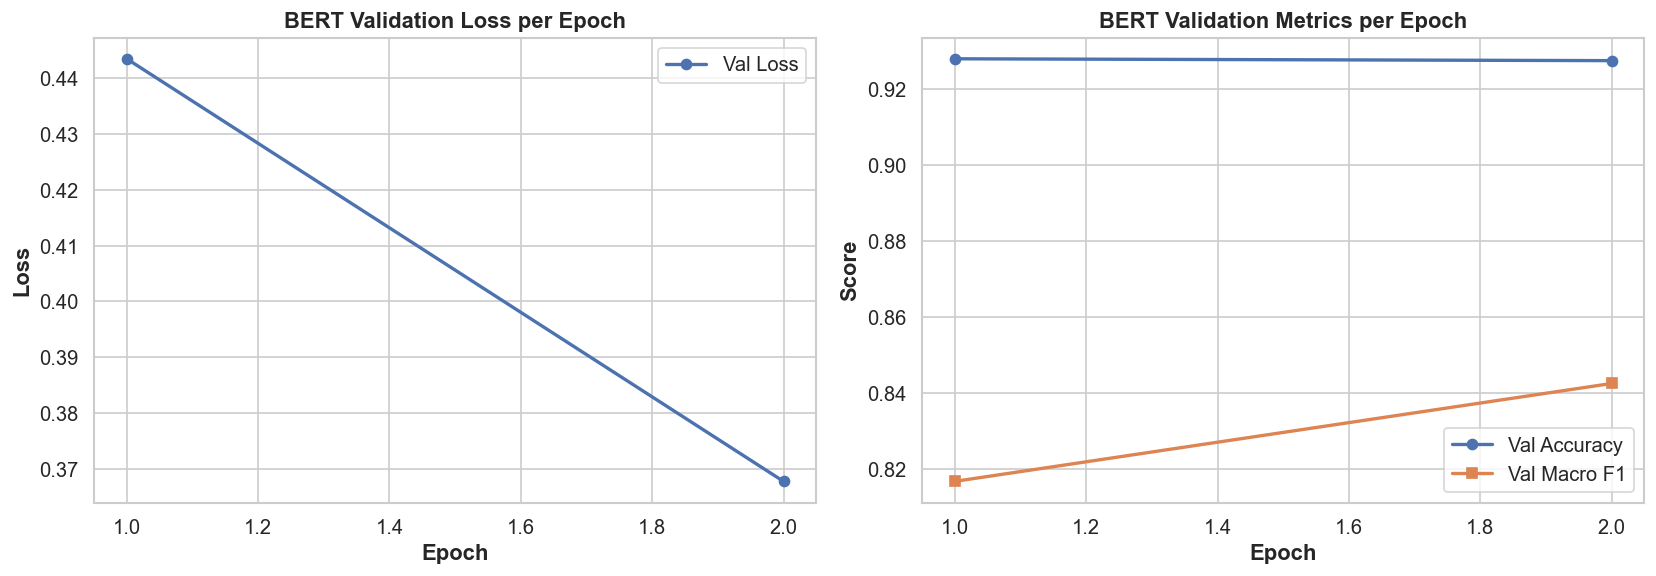

In [50]:
# Training curves
log_history = trainer.state.log_history

# Extract metrics per epoch
train_losses = [x['loss'] for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_entries  = [x for x in log_history if 'eval_loss' in x]
eval_losses   = [x['eval_loss'] for x in eval_entries]
eval_accs     = [x['eval_accuracy'] for x in eval_entries]
eval_f1s      = [x['eval_f1'] for x in eval_entries]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(eval_losses)+1), eval_losses, marker='o', linewidth=2, label='Val Loss')
axes[0].set_xlabel('Epoch', fontweight='bold')
axes[0].set_ylabel('Loss', fontweight='bold')
axes[0].set_title('BERT Validation Loss per Epoch', fontweight='bold')
axes[0].legend()

axes[1].plot(range(1, len(eval_accs)+1), eval_accs, marker='o', linewidth=2, label='Val Accuracy')
axes[1].plot(range(1, len(eval_f1s)+1), eval_f1s, marker='s', linewidth=2, label='Val Macro F1')
axes[1].set_xlabel('Epoch', fontweight='bold')
axes[1].set_ylabel('Score', fontweight='bold')
axes[1].set_title('BERT Validation Metrics per Epoch', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('bert_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

BERT Test Set Results
  Accuracy  : 0.9101
  Macro F1  : 0.8270
  Precision : 0.6071
  Recall    : 0.8465
  ROC-AUC   : 0.9543

              precision    recall  f1-score   support

        Fair       0.98      0.92      0.95      1639
      Unfair       0.61      0.85      0.71       241

    accuracy                           0.91      1880
   macro avg       0.79      0.88      0.83      1880
weighted avg       0.93      0.91      0.92      1880



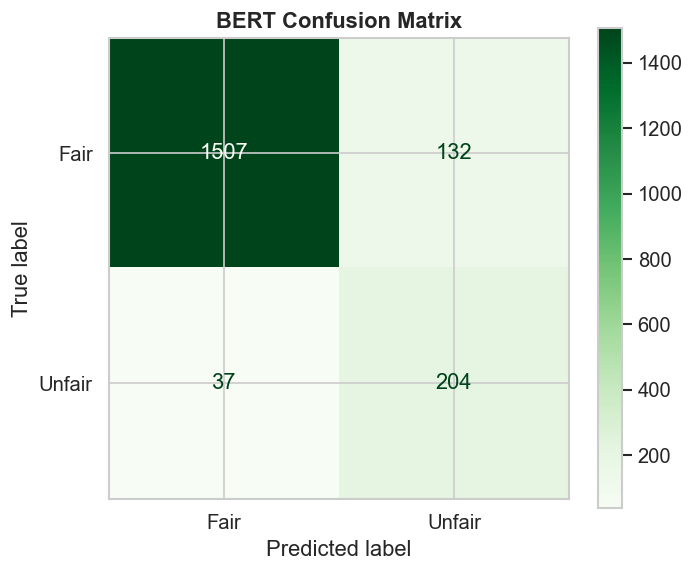

In [51]:
# Evaluating BERT on test set
predictions = trainer.predict(test_dataset)
logits = predictions.predictions
y_proba_bert_test = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
y_pred_bert_test  = np.argmax(logits, axis=1)

print("BERT Test Set Results")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_bert_test):.4f}")
print(f"  Macro F1  : {f1_score(y_test, y_pred_bert_test, average='macro'):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_bert_test):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_bert_test):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_proba_bert_test):.4f}")
print()
print(classification_report(y_test, y_pred_bert_test, target_names=['Fair', 'Unfair']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_bert_test),
                       display_labels=['Fair', 'Unfair']).plot(ax=ax, cmap='Greens', values_format='d')
ax.set_title('BERT Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('bert_cm.png', dpi=150, bbox_inches='tight')
plt.show()

results['BERT'] = {
    'Accuracy':  accuracy_score(y_test, y_pred_bert_test),
    'Macro F1':  f1_score(y_test, y_pred_bert_test, average='macro'),
    'F1 Fair':   f1_score(y_test, y_pred_bert_test, average='binary', pos_label=0),
    'F1 Unfair': f1_score(y_test, y_pred_bert_test, average='binary', pos_label=1),
    'ROC-AUC':   roc_auc_score(y_test, y_proba_bert_test)
}

## 15. Hyperparameter Tuning 

### 15.1 SVM Regularisation Parameter (C), Grid Search

The regularisation parameter C controls the trade-off between maximising the margin and minimising the classification error. I searched over C = [0.01, 0.1, 1.0, 10.0] using 3-fold cross-validation scored on macro F1.

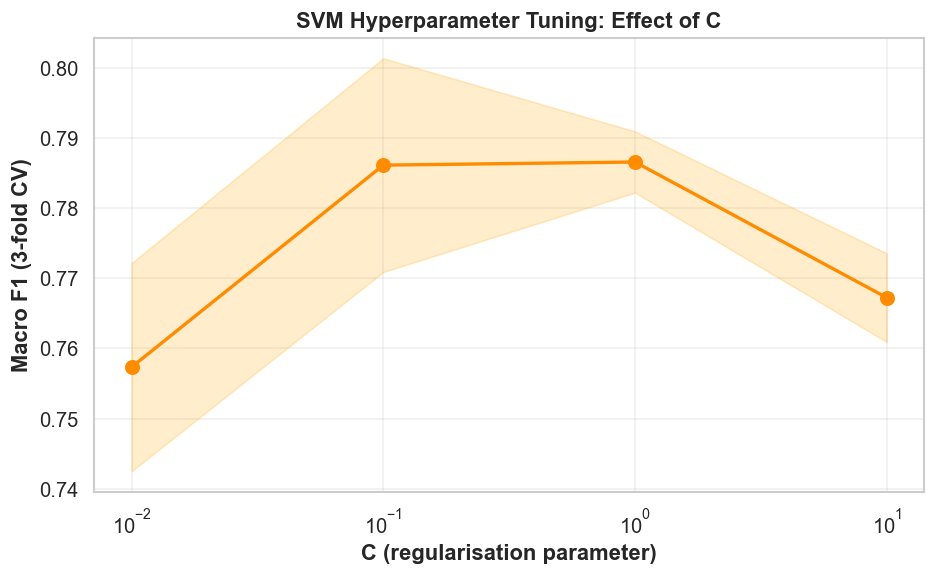

Best C: 1.0 → Macro F1 = 0.7866


In [52]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cv_results['param_C'].astype(float), cv_results['mean_test_score'],
        marker='o', linewidth=2, color='darkorange', markersize=8)
ax.fill_between(cv_results['param_C'].astype(float),
                cv_results['mean_test_score'] - cv_results['std_test_score'],
                cv_results['mean_test_score'] + cv_results['std_test_score'],
                alpha=0.2, color='orange')
ax.set_xscale('log')
ax.set_xlabel('C (regularisation parameter)', fontweight='bold')
ax.set_ylabel('Macro F1 (3-fold CV)', fontweight='bold')
ax.set_title('SVM Hyperparameter Tuning: Effect of C', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('svm_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best C: {grid_search.best_params_['C']} → Macro F1 = {grid_search.best_score_:.4f}")

### 15.2 LSTM Dropout Regularisation

Dropout randomly deactivates neurons during training, forcing the network to learn more robust features. Therefore an LSTM **without** dropout will be compared  to the regularised version.

In [53]:
# Building LSTM without dropout for comparison
def build_lstm_no_reg():
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
        Bidirectional(LSTM(64, return_sequences=False)),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

lstm_no_reg = build_lstm_no_reg()

history_no_reg = lstm_no_reg.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15, batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3,
               restore_best_weights=True, verbose=0)],
    verbose=0
)

y_pred_no_reg = (lstm_no_reg.predict(X_test_pad).flatten() >= 0.5).astype(int)
f1_no_reg   = f1_score(y_test, y_pred_no_reg, average='macro')
f1_with_reg = results['LSTM']['Macro F1']

print("Effect of Dropout Regularisation on LSTM:")
print(f"  WITHOUT dropout — Macro F1: {f1_no_reg:.4f}")
print(f"  WITH dropout    — Macro F1: {f1_with_reg:.4f}")
print(f"  Improvement:                 {f1_with_reg - f1_no_reg:+.4f}")

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Effect of Dropout Regularisation on LSTM:
  WITHOUT dropout — Macro F1: 0.7824
  WITH dropout    — Macro F1: 0.7654
  Improvement:                 -0.0170


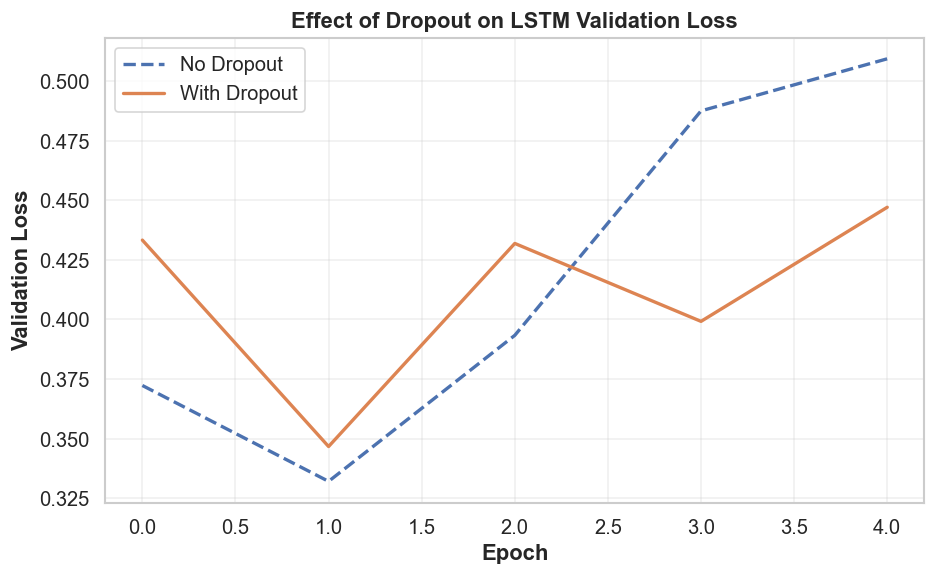

In [54]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_no_reg.history['val_loss'], label='No Dropout', linewidth=2, linestyle='--')
ax.plot(history_lstm.history['val_loss'], label='With Dropout', linewidth=2)
ax.set_xlabel('Epoch', fontweight='bold')
ax.set_ylabel('Validation Loss', fontweight='bold')
ax.set_title('Effect of Dropout on LSTM Validation Loss', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_regularisation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Results Comparison

In [55]:
results_df = pd.DataFrame(results).T.round(4)
results_df.index.name = 'Model'

print("FINAL RESULTS FOR ALL MODELS ON TEST SET")
print(results_df.to_string())
print()
print(f"Best model by Macro F1: {results_df['Macro F1'].idxmax()} "
      f"({results_df['Macro F1'].max():.4f})")

FINAL RESULTS FOR ALL MODELS ON TEST SET
             Accuracy  Macro F1  F1 Fair  F1 Unfair  ROC-AUC
Model                                                       
Naive Bayes    0.9011    0.6894   0.9458     0.4329   0.9119
SVM            0.9266    0.8173   0.9586     0.6761   0.9352
LSTM           0.8580    0.7654   0.9128     0.6180   0.9403
BERT           0.9101    0.8270   0.9469     0.7071   0.9543

Best model by Macro F1: BERT (0.8270)


### 16.2 Grouped Bar Chart

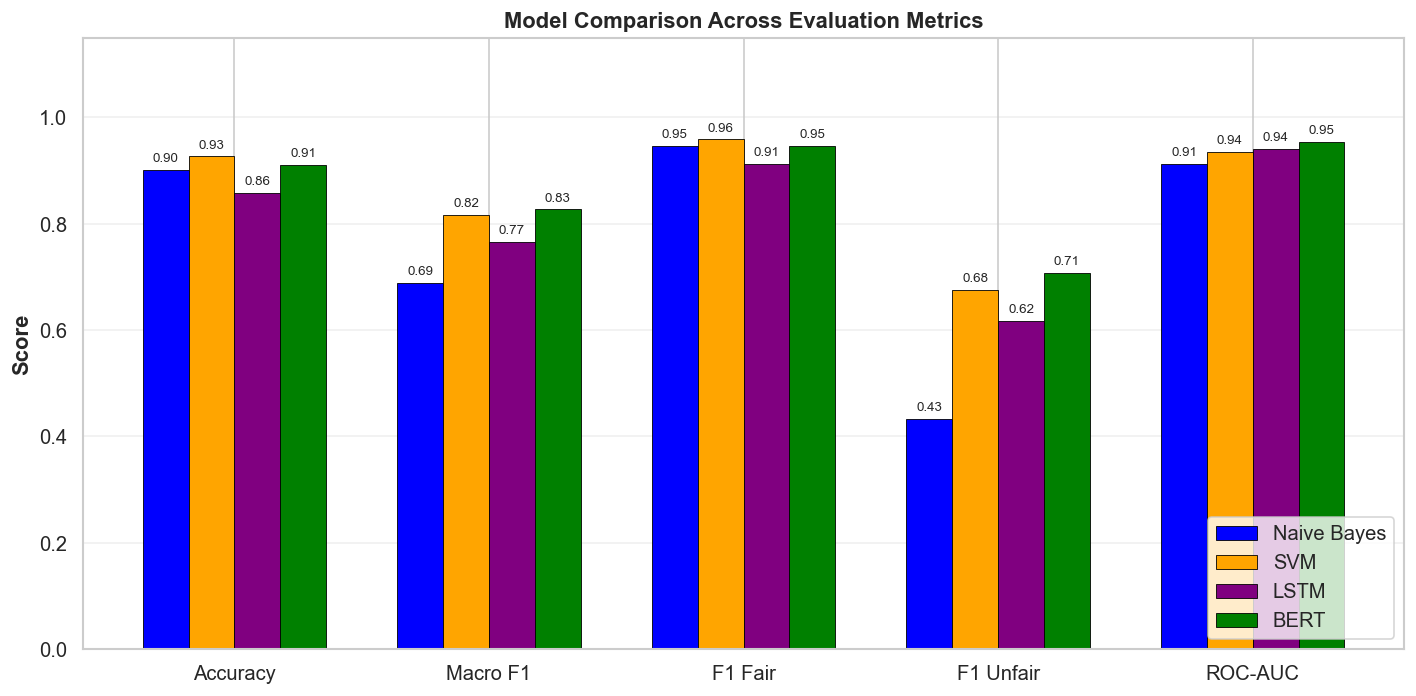

In [57]:
fig, ax = plt.subplots(figsize=(12, 6))
metrics_to_plot = ['Accuracy', 'Macro F1', 'F1 Fair', 'F1 Unfair', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.18
model_colours = ['blue', 'orange', 'purple', 'green']

for i, (model_name, colour) in enumerate(zip(results_df.index, model_colours)):
    values = [results_df.loc[model_name, m] for m in metrics_to_plot]
    bars = ax.bar(x + i*width, values, width, label=model_name,
                  color=colour, edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Model Comparison Across Evaluation Metrics', fontweight='bold')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('All_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 16.3 Confusion Matrices for All Models

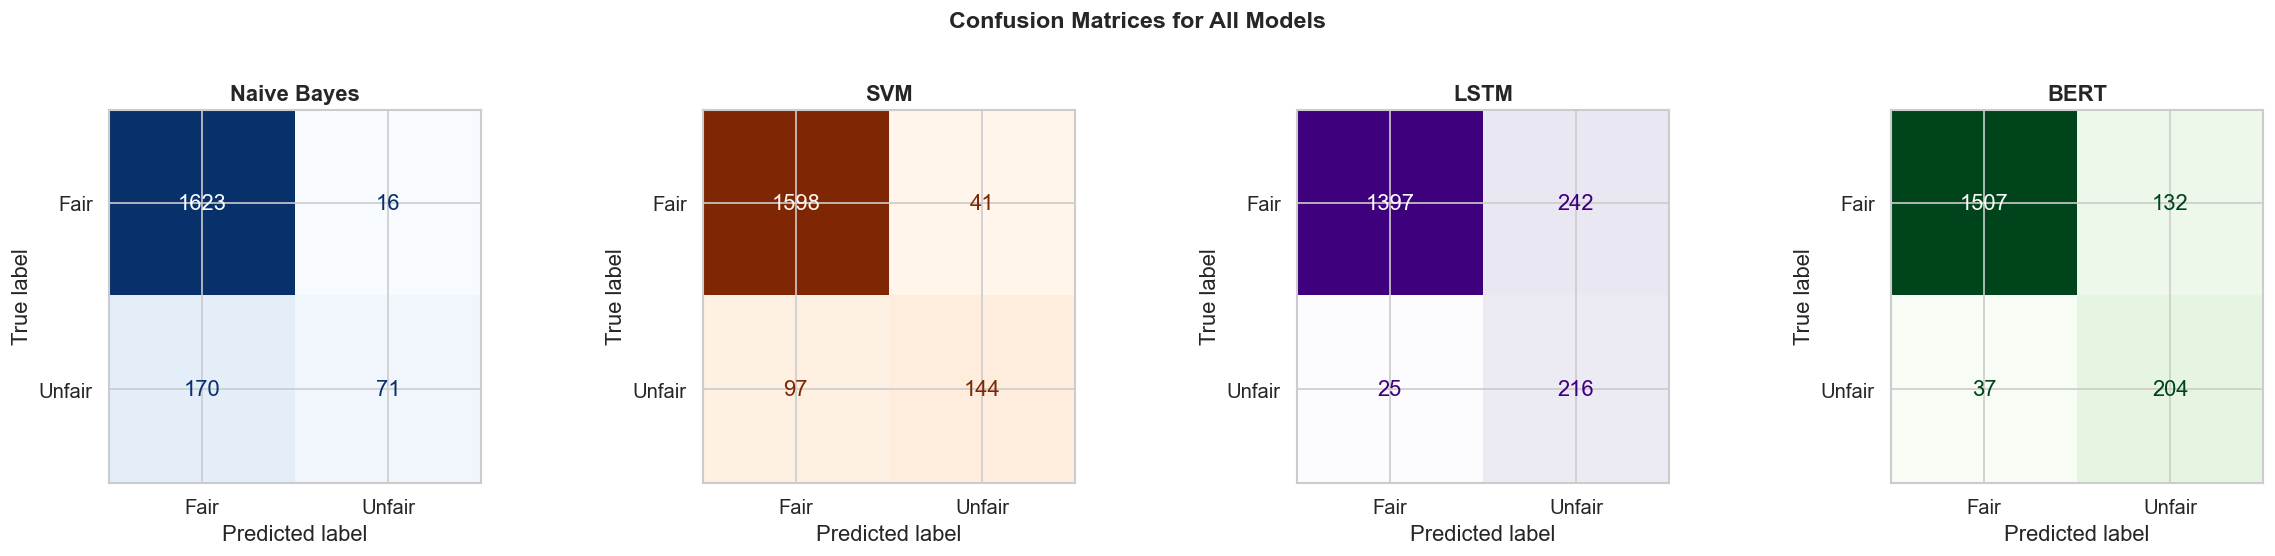

In [58]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
predictions = {'Naive Bayes': y_pred_nb_test, 'SVM': y_pred_svm_test,
                'LSTM': y_pred_lstm_test, 'BERT': y_pred_bert_test}
cmaps = ['Blues', 'Oranges', 'Purples', 'Greens']

for ax, (name, y_pred), cmap in zip(axes, predictions.items(), cmaps):
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                           display_labels=['Fair', 'Unfair']).plot(
                           ax=ax, cmap=cmap, values_format='d', colorbar=False)
    ax.set_title(name, fontweight='bold')

plt.suptitle('Confusion Matrices for All Models', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('All_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 16.4 Discussion

**Key observations:**

1. **Majority class baseline** achieves ~89% accuracy but 0% F1 on unfair, confirming accuracy alone is misleading for this imbalanced dataset.

2. **Naive Bayes** offers a fast probabilistic baseline but struggles with recall on the minority class due to its inability to incorporate class weights.

3. **SVM** with balanced class weights is a strong performer. This aligns with with Lippi et al. (2019), who also used SVM based methods in the original CLAUDETTE system and reported per-category F1 scores of 0.40 - 0.75.

4. **LSTM** captures sequential patterns in legal text and benefits from class weighting and dropout regularisation. However, due to limited data for learning embeddings from scratch, it may underperform transformer based models.

5. **BERT** uses pre trained contextual representations and bidirectional self attention. It achieved the highest macro F1, aligning with the LexGLUE benchmark results (Chalkidis et al., 2022), where transformer models achieved macro F1 of ~0.78 on the UNFAIR-ToS task.